In [22]:
!pip install import-ipynb
import matplotlib.pyplot as plt
import torch
import torchvision
import import_ipynb
import shutil
import os

from torch import nn
from torchvision import transforms
from helper_functions import set_seeds

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [24]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False
    
# 4. Change the classifier head 
class_names = ['daisy','dandelion']

set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)
# pretrained_vit # uncomment for model output 

In [25]:
!pip install torchinfo
from torchinfo import summary

# Print a summary using torchinfo (uncomment for actual output)
summary(model=pretrained_vit, 
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 2]              768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

In [26]:
# Setup directory paths to train and test images
train_dir = 'custom_data/train'
valid_dir = 'custom_data/valid'
test_dir = 'custom_data/test'

for folder in [train_dir, valid_dir, test_dir]:
    checkpoint_folder = os.path.join(folder, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_folder):
        shutil.rmtree(checkpoint_folder)
        print(f"Removed: {checkpoint_folder}")

In [27]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(train_dir: str, valid_dir: str, test_dir: str, transform: transforms.Compose, batch_size: int, num_workers: int=NUM_WORKERS ):

  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  valid_data = datasets.ImageFolder(valid_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)

  # Get class names
  class_names = train_data.classes

  pin_memory = torch.cuda.is_available()  
    
  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=pin_memory,
  )

  valid_dataloader = DataLoader(
      valid_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=pin_memory,
  )
    
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=pin_memory,
  )

  return train_dataloader, valid_dataloader, test_dataloader, class_names

In [29]:
# Setup dataloaders
train_dataloader_pretrained, valid_dataloader_pretrained, test_dataloader_pretrained, class_names = create_dataloaders(train_dir=train_dir,
                                                                                                     valid_dir=valid_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=pretrained_vit_transforms,
                                                                                                     batch_size=32)

In [30]:
from engine import train

# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(), lr=1e-5)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
pretrained_vit_results = train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      val_dataloader=valid_dataloader_pretrained,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=20,
                                      device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7510 | train_acc: 0.4148 | val_loss: 0.7256 | val_acc: 0.4771
Epoch: 2 | train_loss: 0.7094 | train_acc: 0.4897 | val_loss: 0.6853 | val_acc: 0.5451
Epoch: 3 | train_loss: 0.6710 | train_acc: 0.5587 | val_loss: 0.6487 | val_acc: 0.6128
Epoch: 4 | train_loss: 0.6363 | train_acc: 0.6272 | val_loss: 0.6156 | val_acc: 0.7043
Epoch: 5 | train_loss: 0.6045 | train_acc: 0.7023 | val_loss: 0.5848 | val_acc: 0.7516
Epoch: 6 | train_loss: 0.5757 | train_acc: 0.7662 | val_loss: 0.5571 | val_acc: 0.7929
Epoch: 7 | train_loss: 0.5494 | train_acc: 0.8089 | val_loss: 0.5315 | val_acc: 0.8215
Epoch: 8 | train_loss: 0.5255 | train_acc: 0.8263 | val_loss: 0.5084 | val_acc: 0.8319
Epoch: 9 | train_loss: 0.5039 | train_acc: 0.8371 | val_loss: 0.4874 | val_acc: 0.8424
Epoch: 10 | train_loss: 0.4839 | train_acc: 0.8466 | val_loss: 0.4680 | val_acc: 0.8528
Epoch: 11 | train_loss: 0.4658 | train_acc: 0.8569 | val_loss: 0.4503 | val_acc: 0.8580
Epoch: 12 | train_loss: 0.4491 | train_ac

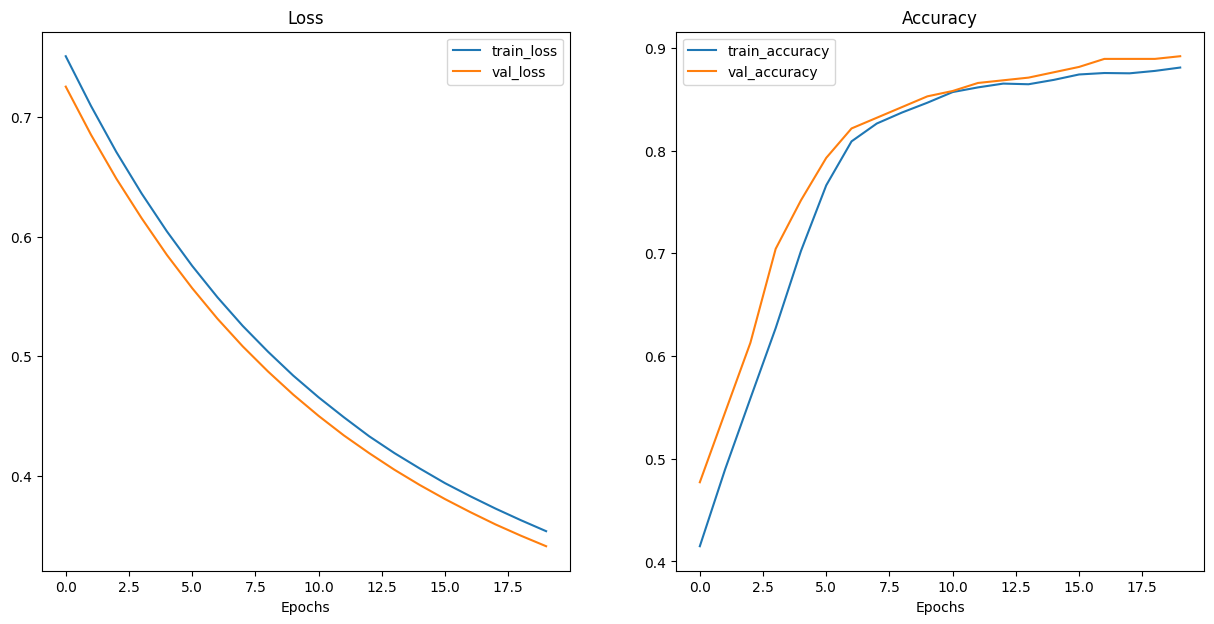

In [31]:
# Plot the loss curves
from helper_functions import plot_loss_curves, plot_predictions, accuracy_fn, get_predictions

plot_loss_curves(pretrained_vit_results)

In [32]:
from engine import test_step

test_loss, test_acc = test_step(model=pretrained_vit,
                               dataloader=test_dataloader_pretrained,
                               loss_fn=loss_fn,
                               device=device)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3337 | Test Accuracy: 0.9067


[[73  4]
 [13 92]]


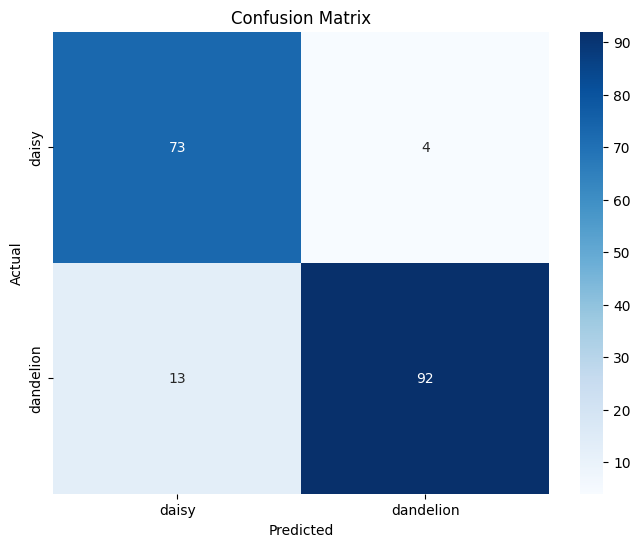

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_preds, test_labels = get_predictions(pretrained_vit, test_dataloader_pretrained, device)

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
# Use your accuracy function
test_accuracy = accuracy_fn(y_true=test_labels, y_pred=test_preds)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 90.66%


In [35]:
torch.save(pretrained_vit.state_dict(), 'vit_trained_model.pth')